<a href="https://colab.research.google.com/github/deepali-ds/Air-pollution-dashboard/blob/main/Plume_Detection_LightGBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##########*************************************************#############

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import average_precision_score, f1_score
from sklearn.cluster import DBSCAN
import geopandas as gpd
from shapely.geometry import Point
import joblib

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Europe_features_monthly_aggregation/labeled_dataset.csv")

print("Loaded:", df.shape, df.columns)

Loaded: (2122960, 48) Index(['system:index', 'BSI_mean', 'BSI_stdDev', 'NDBI_mean', 'NDBI_stdDev',
       'NDMI_mean', 'NDMI_stdDev', 'NDVI_mean', 'NDVI_stdDev', 'NDWI_mean',
       'NDWI_stdDev', 'SWIR1_mean', 'SWIR1_stdDev', 'SWIR2_mean',
       'SWIR2_stdDev', 'elevation_mean', 'elevation_stdDev', 'hex_id',
       'infra_distance_mean', 'infra_distance_stdDev', 'lat', 'lon', 'month',
       'nightlights_mean', 'nightlights_stdDev', 'slope_mean', 'slope_stdDev',
       'wind_direction_mean', 'wind_direction_stdDev', 'wind_speed_mean',
       'wind_speed_stdDev', 'year', '.geo', 'source_file', 'CH4_mean_mean',
       'CH4_mean_stdDev', 'CH4_persistence_mean', 'CH4_persistence_stdDev',
       'CH4_std_mean', 'CH4_std_stdDev', 'CH4_zscore_mean',
       'CH4_zscore_stdDev', 'label_unep', 'CH4_thresh_95', 'label_thresh',
       'label_combined', 'rolling_sum', 'final_label'],
      dtype='object')


In [ ]:
df = df.copy()
df = df.sort_values(["hex_id", "year", "month"])

In [ ]:
emit = pd.read_csv("/content/drive/MyDrive/Spain_EMIT_L2B/Spain_EMIT_monthly_FINAL_WORKING.csv")

df = df.merge(
    emit[["system:index", "emit_ch4_z"]],
    on="system:index",
    how="left"
)

In [ ]:
emit.columns

Index(['system:index', 'date', 'emit_ch4_z', 'emit_ch4_z_mean',
       'emit_ch4_z_sum', 'hex_id', 'month', 'plume_freq', 'plume_mask_mean',
       'plume_mask_sum', 'scene_count', 'year', '.geo'],
      dtype='object')

In [ ]:
df.columns

Index(['system:index', 'BSI_mean', 'BSI_stdDev', 'NDBI_mean', 'NDBI_stdDev',
       'NDMI_mean', 'NDMI_stdDev', 'NDVI_mean', 'NDVI_stdDev', 'NDWI_mean',
       'NDWI_stdDev', 'SWIR1_mean', 'SWIR1_stdDev', 'SWIR2_mean',
       'SWIR2_stdDev', 'elevation_mean', 'elevation_stdDev', 'hex_id',
       'infra_distance_mean', 'infra_distance_stdDev', 'lat', 'lon', 'month',
       'nightlights_mean', 'nightlights_stdDev', 'slope_mean', 'slope_stdDev',
       'wind_direction_mean', 'wind_direction_stdDev', 'wind_speed_mean',
       'wind_speed_stdDev', 'year', '.geo', 'source_file', 'CH4_mean_mean',
       'CH4_mean_stdDev', 'CH4_persistence_mean', 'CH4_persistence_stdDev',
       'CH4_std_mean', 'CH4_std_stdDev', 'CH4_zscore_mean',
       'CH4_zscore_stdDev', 'label_unep', 'CH4_thresh_95', 'label_thresh',
       'label_combined', 'rolling_sum', 'final_label', 'emit_ch4_z'],
      dtype='object')

In [ ]:
hex_p95 = (
    df.groupby("hex_id")["CH4_mean_mean"]
    .quantile(0.95)
    .rename("hex_p95")
)

df = df.merge(hex_p95, on="hex_id", how="left")

df["target_anomaly"] = (df["CH4_mean_mean"] > df["hex_p95"]).astype(int)

In [ ]:
df["CH4_lag1"] = df.groupby("hex_id")["CH4_mean_mean"].shift(1)
df["CH4_lag2"] = df.groupby("hex_id")["CH4_mean_mean"].shift(2)

df["CH4_roll3"] = (
    df.groupby("hex_id")["CH4_mean_mean"]
    .rolling(3, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

df[["CH4_lag1","CH4_lag2","CH4_roll3"]] = df[
    ["CH4_lag1","CH4_lag2","CH4_roll3"]
].fillna(0)

In [ ]:
features_model = [
    "CH4_mean_mean",
    "CH4_lag1",
    "CH4_lag2",
    "CH4_roll3",
    "CH4_persistence_mean",
    "NDVI_mean",
    "wind_speed_mean",
    "nightlights_mean"
]

target = "target_anomaly"

In [ ]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)

train_idx, temp_idx = next(gss.split(df, groups=df["hex_id"]))

train_df = df.iloc[train_idx]
temp_df = df.iloc[temp_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)

val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df["hex_id"]))

val_df = temp_df.iloc[val_idx]
test_df = temp_df.iloc[test_idx]

In [ ]:
X_train = train_df[features_model]
y_train = train_df[target]

X_val = val_df[features_model]
y_val = val_df[target]

X_test = test_df[features_model]
y_test = test_df[target]

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = lgb.LGBMClassifier(
    n_estimators=600,
    learning_rate=0.05,
    num_leaves=64,
    scale_pos_weight=pos_weight,
    random_state=42
)

model.fit(X_train, y_train)

val_pred = model.predict_proba(X_val)[:,1]
test_pred = model.predict_proba(X_test)[:,1]

print("VAL PR-AUC:", average_precision_score(y_val, val_pred))
print("TEST PR-AUC:", average_precision_score(y_test, test_pred))

[LightGBM] [Info] Number of positive: 24314, number of negative: 1461766
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.089173 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 1486080, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.016361 -> initscore=-4.096348
[LightGBM] [Info] Start training from score -4.096348
VAL PR-AUC: 0.7107494290902299
TEST PR-AUC: 0.7090069864406123


In [ ]:
joblib.dump(model, "/content/drive/MyDrive/Europe_features_monthly_aggregation/methane_models/lgb_methane_model.pkl")

['/content/drive/MyDrive/Europe_features_monthly_aggregation/methane_models/lgb_methane_model.pkl']

In [ ]:
print(len(y_test), len(test_pred))
print("Positives:", (y_test == 1).sum())

318480 318480
Positives: 5009


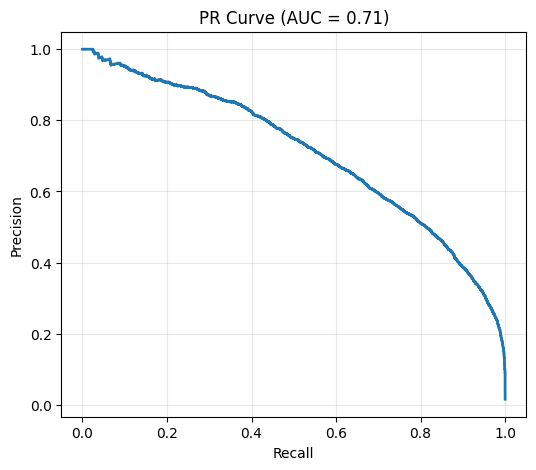

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Safety check
assert "y_test" in locals(), "Run training cell first"
assert "test_pred" in locals(), "Run prediction first"

precision, recall, _ = precision_recall_curve(y_test, test_pred)
pr_auc = average_precision_score(y_test, test_pred)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, linewidth=2)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"PR Curve (AUC = {pr_auc:.2f})")

plt.grid(alpha=0.3)

plt.savefig("pr_curve.png", dpi=300, bbox_inches="tight")
plt.savefig("pr_curve.pdf", bbox_inches="tight")

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# compute PR curve
precision, recall, thresholds = precision_recall_curve(y_test, test_pred)

# remove last point mismatch
thresholds = thresholds

# compute F1
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-9)

# best threshold
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print("Best Threshold:", best_threshold)
print("Best F1:", best_f1)

Best Threshold: 0.9553184899014101
Best F1: 0.6467089219771075


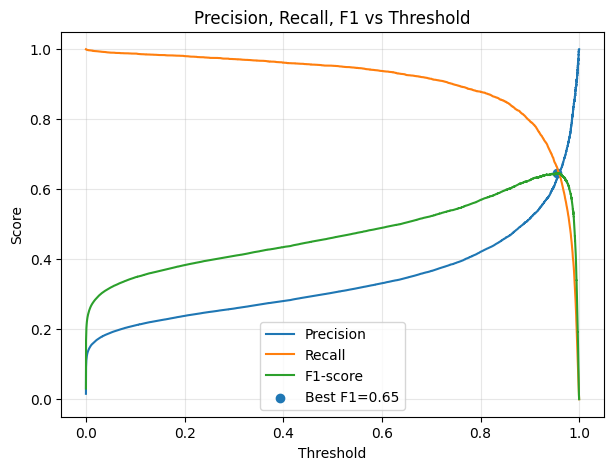

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.plot(thresholds, f1_scores, label="F1-score")

# mark best point
plt.scatter(
    best_threshold,
    best_f1,
    marker="o",
    label=f"Best F1={best_f1:.2f}"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, F1 vs Threshold")

plt.legend()
plt.grid(alpha=0.3)

plt.savefig("threshold_curve.png", dpi=300, bbox_inches="tight")
plt.savefig("threshold_curve.pdf", bbox_inches="tight")

plt.show()

In [ ]:
# Full prediction
df["risk_score"] = model.predict_proba(df[features_model])[:,1]

In [ ]:
# Spatial smoothing
df["lat_r"] = df["lat"].round(2)
df["lon_r"] = df["lon"].round(2)

spatial = (
    df.groupby(["lat_r","lon_r"])["risk_score"]
    .mean()
    .rename("risk_spatial")
)

df = df.merge(spatial, on=["lat_r","lon_r"], how="left")

df["risk_smooth"] = (
    0.7 * df["risk_score"] +
    0.3 * df["risk_spatial"]
)

In [ ]:
df = df.merge(
    emit[["hex_id", "year", "month", "emit_ch4_z", "plume_freq", "scene_count"]],
    on=["hex_id", "year", "month"],
    how="left"
)

In [ ]:
print([c for c in df.columns if "emit" in c or "plume" in c])

['emit_ch4_z_x', 'emit_ch4_z_y', 'plume_freq']


In [ ]:
df["emit_ch4_z"] = df["emit_ch4_z_y"]

# Drop duplicates
df = df.drop(columns=[
    "emit_ch4_z_x",
    "emit_ch4_z_y"
])

In [ ]:
print([c for c in df.columns if "emit" in c])

['emit_ch4_z']


In [ ]:
df["emit_ch4_z"] = df["emit_ch4_z"].fillna(0)

df["plume_freq"] = df["plume_freq"].fillna(0)
df["scene_count"] = df["scene_count"].fillna(1)

df["plume_freq_norm"] = df["plume_freq"] / (df["scene_count"] + 1e-6)

In [ ]:
df["emit_ch4_z"] = df.get("emit_ch4_z", 0)
df["plume_freq"] = df.get("plume_freq", 0)
df["scene_count"] = df.get("scene_count", 1)

In [ ]:
# Normalization
df["plume_freq_norm"] = df["plume_freq"] / (df["scene_count"] + 1e-6)

In [ ]:
# Create EMIT availability flag
df["emit_available"] = (df["emit_ch4_z"] != 0).astype(int)

In [ ]:
# EMIT fusion
df["fusion_score"] = (
    0.7 * df["risk_smooth"] +
    0.2 * df["emit_ch4_z"] +
    0.1 * df["plume_freq_norm"]
)

df["fusion_score"] = np.where(
    df["emit_available"] == 1,
    df["fusion_score"],
    df["risk_smooth"]
)

In [ ]:
# Threshold tuning
threshold = df["fusion_score"].quantile(0.995)

In [ ]:
# DBSCAN clustering
candidates = df[df["fusion_score"] > threshold].copy()

coords = candidates[["lat","lon"]].values

db = DBSCAN(eps=0.05, min_samples=5).fit(coords)

candidates["cluster"] = db.labels_

plumes = candidates[candidates["cluster"] != -1]

In [ ]:
# Aggregate plumes
plume_objects = (
    plumes.groupby("cluster")
    .agg({
        "lat": "mean",
        "lon": "mean",
        "fusion_score": "max",
        "hex_id": "count"
    })
    .rename(columns={"hex_id": "size"})
    .reset_index()
)

print("Final plume objects:", len(plume_objects))

Final plume objects: 863


In [ ]:
# Export Geojson
plume_objects["geometry"] = plume_objects.apply(
    lambda r: Point(r["lon"], r["lat"]), axis=1
)

gdf = gpd.GeoDataFrame(plume_objects, geometry="geometry", crs="EPSG:4326")

gdf.to_file("final_plumes.geojson", driver="GeoJSON")

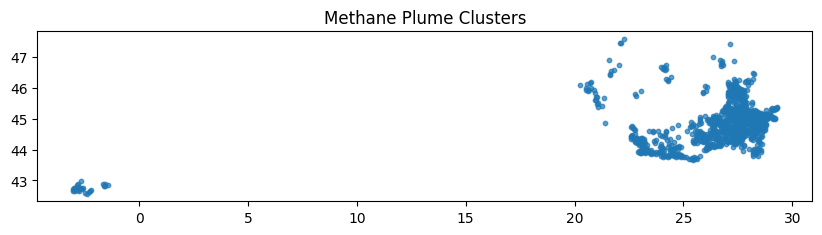

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf = gpd.read_file("final_plumes.geojson")

fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    ax=ax,
    markersize=10,
    alpha=0.7
)

plt.title("Methane Plume Clusters")
plt.show()

In [ ]:
import folium
import geopandas as gpd

gdf = gpd.read_file("/content/final_plumes.geojson")

# center map
center = [gdf.geometry.y.mean(), gdf.geometry.x.mean()]

m = folium.Map(location=center, zoom_start=6, tiles="CartoDB positron")

for _, row in gdf.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=5,
        popup=f"Score: {row.get('fusion_score', 'NA')}",
        color="red",
        fill=True,
        fill_opacity=0.7
    ).add_to(m)

m

In [ ]:
! pip install keplergl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.4/18.4 MB 31.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached jupyter_packaging-0.12.3-py3-none-any.whl.metadata (7.7 kB)
  Using cached comm-0.2.3-py3-none-any.whl.metadata (3.7 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached async_lru-2.3.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached jupyter_lsp-2.3.1-py3-none-any.whl.metadata (1.8 kB)
  Using cached jupyterlab_server-2.28.0-py3-none-any.whl.metadata (5.9 kB)
  Using cached jedi-0.19.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached json5-0.14.0-py3-none-any.whl.metadata (36 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Using cached jupyter_packaging-0.12.3-py3-none-any.whl (15 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/1

In [ ]:
from keplergl import KeplerGl
import geopandas as gpd

gdf = gpd.read_file("final_plumes.geojson")

map_1 = KeplerGl(height=600)
map_1.add_data(data=gdf, name="methane_plumes")

map_1

User Guide: https://docs.kepler.gl/docs/keplergl-jupyter


KeplerGl(data={'methane_plumes': {'index': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, …

   cluster        lat       lon  fusion_score  size                   geometry
0        0  42.847125 -1.420769      0.761673     5  POINT (-1.42077 42.84712)
1        1  42.869819 -1.572036      0.766754     7  POINT (-1.57204 42.86982)
2        2  42.813648 -1.544516      0.772603     8  POINT (-1.54452 42.81365)
3        3  42.881101 -1.647784      0.792528    10   POINT (-1.64778 42.8811)
4        4  42.824930 -1.620181      0.763670     5  POINT (-1.62018 42.82493)
Total plumes: 863


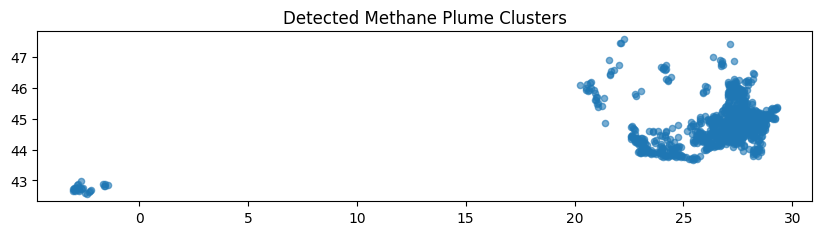

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf = gpd.read_file("/content/final_plumes.geojson")

print(gdf.head())
print("Total plumes:", len(gdf))

fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    ax=ax,
    markersize=20,
    alpha=0.6
)

plt.title("Detected Methane Plume Clusters")
plt.show()

In [ ]:
import folium
import geopandas as gpd

gdf = gpd.read_file("final_plumes.geojson")

center = [gdf.geometry.y.mean(), gdf.geometry.x.mean()]

m = folium.Map(location=center, zoom_start=6, tiles="CartoDB positron")

for _, row in gdf.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=6,
        popup=folium.Popup(
            f"""
            <b>Severity:</b> {row.get('severity_score', 'NA')}<br>
            <b>Fusion:</b> {row.get('max_fusion', 'NA')}<br>
            <b>Size:</b> {row.get('size', 'NA')}
            """,
            max_width=300
        ),
        color="red",
        fill=True,
        fill_opacity=0.7
    ).add_to(m)

m

In [ ]:
top20 = gdf.sort_values("fusion_score", ascending=False).head(20)

top20[[
    "cluster",
    "fusion_score",
    "size",
    "lat",
    "lon"
]]

,cluster,fusion_score,size,lat,lon
191,191,0.825483,14,45.024426,28.905110
201,201,0.817137,15,45.057362,28.974521
694,694,0.812283,13,45.313326,27.812316
196,196,0.809972,11,45.074647,28.748336
574,574,0.809336,11,45.013970,27.713039
772,772,0.809286,11,44.946396,27.574998
774,774,0.809195,8,45.038323,27.634138
194,194,0.808601,10,45.107661,28.817752
190,190,0.808401,12,45.049565,28.826754
186,186,0.808271,12,44.783726,28.793449


In [ ]:
top20.to_csv("top20_methane_leaks.csv", index=False)
gdf.to_csv("all_plumes.csv", index=False)

In [ ]:
import pandas as pd
plumes = pd.read_csv("/content/all_plumes.csv")
plumes.columns

Index(['cluster', 'lat', 'lon', 'fusion_score', 'size', 'geometry'], dtype='object')

In [ ]:
# Plume aggregation
import numpy as np

plume_df = plumes.copy()

# base required columns check
required = ["cluster", "lat", "lon", "fusion_score"]
plume_df = plume_df.dropna(subset=[c for c in required if c in plume_df.columns])

agg_dict = {
    "lat": "mean",
    "lon": "mean",
    "fusion_score": ["max", "mean"],
}

# optional columns (only added if exist)
if "emit_ch4_z" in plume_df.columns:
    agg_dict["emit_ch4_z"] = "max"

if "hex_id" in plume_df.columns:
    agg_dict["hex_id"] = "count"

if "CH4_persistence_mean" in plume_df.columns:
    agg_dict["CH4_persistence_mean"] = "mean"

plume_objects = plume_df.groupby("cluster").agg(agg_dict)

In [ ]:
# Flatten columns
plume_objects.columns = [
    "_".join(col) if isinstance(col, tuple) else col
    for col in plume_objects.columns
]

plume_objects = plume_objects.reset_index()

In [ ]:
# Severity score
score = 0

# fusion signal
if "fusion_score_max" in plume_objects.columns:
    score += 0.5 * plume_objects["fusion_score_max"]

# EMIT signal (robust fallback)
if "emit_ch4_z_max" in plume_objects.columns:
    score += 0.2 * plume_objects["emit_ch4_z_max"]

# size contribution
if "hex_id_count" in plume_objects.columns:
    score += 0.2 * np.log1p(plume_objects["hex_id_count"])

# persistence
if "CH4_persistence_mean_mean" in plume_objects.columns:
    score += 0.1 * plume_objects["CH4_persistence_mean_mean"]

plume_objects["severity_score"] = score

In [ ]:
# Filter false positives
# ensure column exists
if "hex_id_count" in plume_objects.columns:
    size_col = "hex_id_count"
else:
    size_col = None

threshold = plume_objects["severity_score"].quantile(0.5)

if size_col:
    plume_objects = plume_objects[
        (plume_objects[size_col] >= 5) &
        (plume_objects["severity_score"] > threshold)
    ]
else:
    plume_objects = plume_objects[
        plume_objects["severity_score"] > threshold
    ]

In [ ]:
# detect correct lat/lon columns
lat_col = [c for c in plume_objects.columns if "lat" in c][0]
lon_col = [c for c in plume_objects.columns if "lon" in c][0]

In [ ]:
top_leaks = plume_objects.sort_values(
    "severity_score",
    ascending=False
).head(20)

print(
    top_leaks[[
        lat_col,
        lon_col,
        "severity_score"
    ]]
)

      lat_mean   lon_mean  severity_score
191  45.024426  28.905110        0.412742
201  45.057362  28.974521        0.408568
694  45.313326  27.812316        0.406141
196  45.074647  28.748336        0.404986
574  45.013970  27.713039        0.404668
772  44.946396  27.574998        0.404643
774  45.038323  27.634138        0.404598
194  45.107661  28.817752        0.404301
190  45.049565  28.826754        0.404200
186  44.783726  28.793449        0.404136
773  45.062618  27.555177        0.403471
586  44.922065  27.653836        0.403297
703  45.105747  27.772366        0.402995
588  44.888232  27.584887        0.402795
195  45.082538  28.896168        0.402685
696  45.279759  27.742989        0.402683
213  45.297110  29.087043        0.402630
197  45.032128  29.052812        0.402591
575  44.974154  28.018486        0.402466
572  45.047671  27.782131        0.402422


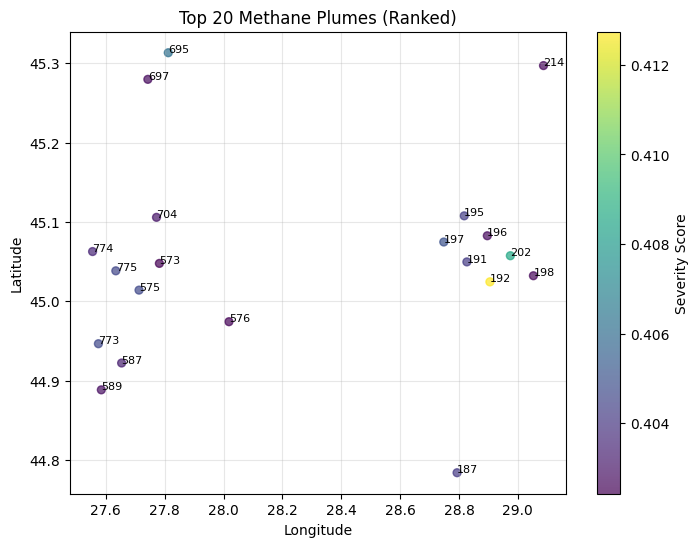

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    top_leaks["lon_mean"],
    top_leaks["lat_mean"],
    s=top_leaks["severity_score"] * 80,
    c=top_leaks["severity_score"],
    alpha=0.7
)

# add labels
for i, row in top_leaks.iterrows():
    plt.text(
        row["lon_mean"],
        row["lat_mean"],
        f"{i+1}",
        fontsize=8
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Top 20 Methane Plumes (Ranked)")

plt.colorbar(label="Severity Score")

plt.grid(alpha=0.3)

plt.savefig("top20_plumes.png", dpi=300, bbox_inches="tight")
plt.savefig("top20_plumes.pdf", bbox_inches="tight")

plt.show()

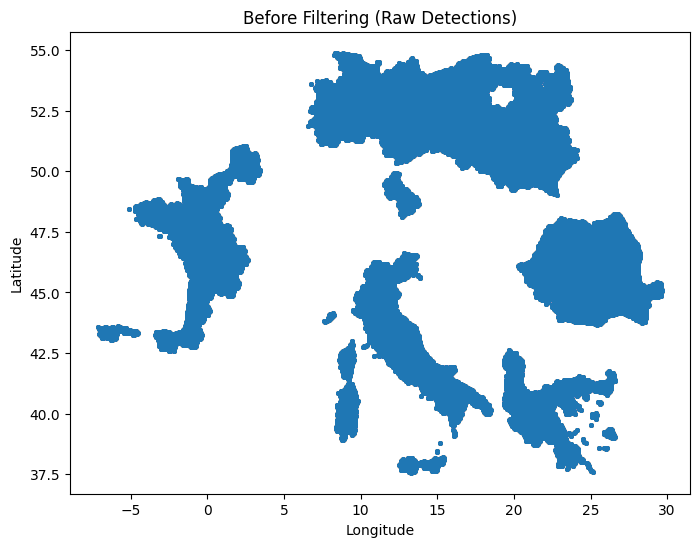

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["lon"],
    df["lat"],
    s=5,
    alpha=0.3
)

plt.title("Before Filtering (Raw Detections)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.savefig("before_filtering.png", dpi=300, bbox_inches="tight")
plt.show()

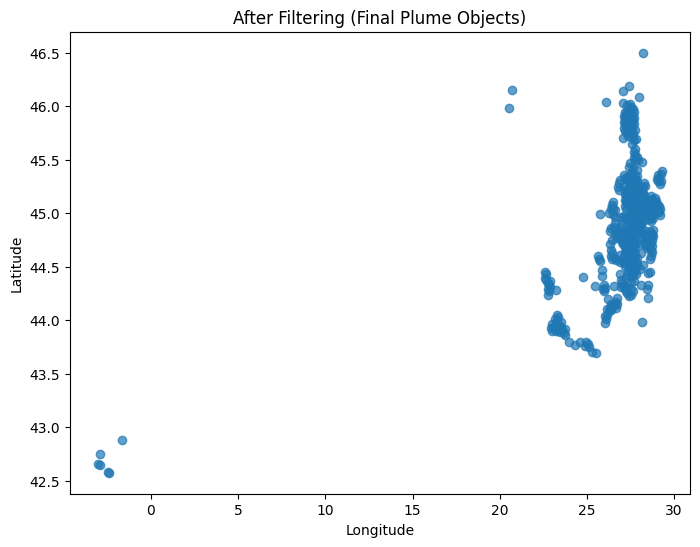

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    plume_objects["lon_mean"],
    plume_objects["lat_mean"],
    #s=plume_objects["size"] * 5,
    alpha=0.7
)

plt.title("After Filtering (Final Plume Objects)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.savefig("after_filtering.png", dpi=300, bbox_inches="tight")
plt.show()

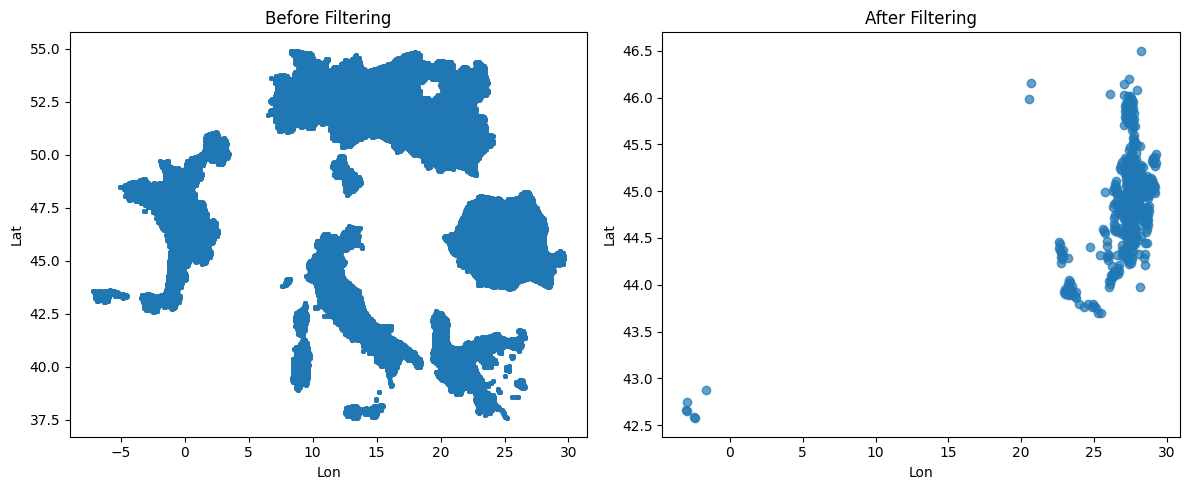

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# before
ax[0].scatter(df["lon"], df["lat"], s=5, alpha=0.3)
ax[0].set_title("Before Filtering")

# after
ax[1].scatter(
    plume_objects["lon_mean"],
    plume_objects["lat_mean"],
    #s=plume_objects["size"] * 5,
    alpha=0.7
)
ax[1].set_title("After Filtering")

for a in ax:
    a.set_xlabel("Lon")
    a.set_ylabel("Lat")

plt.tight_layout()
plt.savefig("before_after.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
from sklearn.metrics import f1_score

# use best threshold
y_pred_binary = (test_pred >= best_threshold).astype(int)

f1 = f1_score(y_test, y_pred_binary)

print("Test F1:", f1)

Test F1: 0.6467089224768405


In [ ]:
top_leaks = top_leaks.reset_index(drop=True)
top_leaks["rank"] = top_leaks.index + 1

print(top_leaks[["rank", "lat_mean", "lon_mean", "severity_score"]])

    rank   lat_mean   lon_mean  severity_score
0      1  45.024426  28.905110        0.412742
1      2  45.057362  28.974521        0.408568
2      3  45.313326  27.812316        0.406141
3      4  45.074647  28.748336        0.404986
4      5  45.013970  27.713039        0.404668
5      6  44.946396  27.574998        0.404643
6      7  45.038323  27.634138        0.404598
7      8  45.107661  28.817752        0.404301
8      9  45.049565  28.826754        0.404200
9     10  44.783726  28.793449        0.404136
10    11  45.062618  27.555177        0.403471
11    12  44.922065  27.653836        0.403297
12    13  45.105747  27.772366        0.402995
13    14  44.888232  27.584887        0.402795
14    15  45.082538  28.896168        0.402685
15    16  45.279759  27.742989        0.402683
16    17  45.297110  29.087043        0.402630
17    18  45.032128  29.052812        0.402591
18    19  44.974154  28.018486        0.402466
19    20  45.047671  27.782131        0.402422


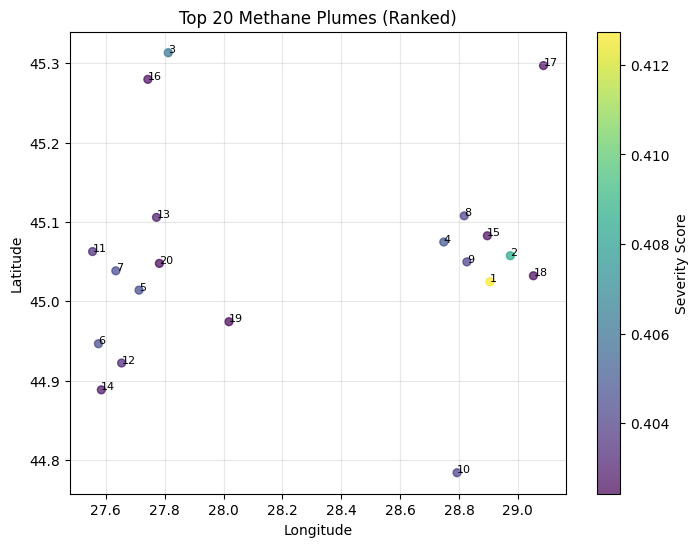

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    top_leaks["lon_mean"],
    top_leaks["lat_mean"],
    s=top_leaks["severity_score"] * 80,
    c=top_leaks["severity_score"],
    alpha=0.7
)

# add labels
for i, row in top_leaks.iterrows():
    plt.text(
        row["lon_mean"],
        row["lat_mean"],
        f"{i+1}",
        fontsize=8
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Top 20 Methane Plumes (Ranked)")

plt.colorbar(label="Severity Score")

plt.grid(alpha=0.3)

plt.savefig("top20_plumes.png", dpi=300, bbox_inches="tight")
plt.savefig("top20_plumes.pdf", bbox_inches="tight")

plt.show()